# Диагностика горизонта зрелости утилизации (T)

## Назначение

Проверка достаточного периода наблюдения `T` при построении исхода «утилизация в
пределах T дней» и анализ чувствительности DiD по альтернативным значениям T.

## Входные данные

Заявки с датами утилизации; параметры совпадают с
`final_empirical_recalculation.ipynb`.

## Результаты

Описательные таблицы, графики чувствительности, `conclusion.md` и CSV в
`outputs/utilization_censoring/`.

## Статус

Диагностический ноутбук, входит в пайплайн выбора горизонта зрелости.

`T` не является оценкой утилизации за весь доступный период. Это горизонт
T-дневной конверсии среди заявок с достаточным периодом наблюдения. Исходные CSV,
классификация гексагонов и основной расчёт не изменяются.


In [1]:
# ============================================================
# Параметры
# ============================================================

import pandas as pd

# Кандидатные горизонты для описательной диагностики
CANDIDATE_THRESHOLDS = [7, 10, 14, 18, 21, 25, 28, 30, 35, 42, 49, 56]

# Горизонты для DiD sensitivity
DID_THRESHOLDS = [21, 25, 28, 35]
DID_THRESHOLDS_EXTENDED = DID_THRESHOLDS + [42]  # 42 — только расширенная sensitivity

REFERENCE_THRESHOLD = 25  # заранее заданный основной горизонт (не «оптимальный»)
MAX_DID_THRESHOLD = 42

CORE_CHANGE_TYPES = ["region_only", "workmode_only", "region_and_workmode"]
TYPE_ORDER = ["region_and_workmode", "region_only", "workmode_only"]

# Как в final_empirical_recalculation для utlz_flg
EXCLUDED_COHORT_FOR_CONVERSION = pd.Timestamp("2022-07-27")
CONVERSION_EXCLUDED_COHORTS = {EXCLUDED_COHORT_FOR_CONVERSION}

STUDY_START = pd.Timestamp("2022-04-01")
STUDY_END = pd.Timestamp("2022-10-18")
EXCLUDED_COHORTS_PIPELINE = {pd.Timestamp("2022-10-19")}

# Административное окончание наблюдения по утилизации (не max(real_utilization_dttm))
UTILIZATION_OBSERVATION_END = pd.Timestamp("2022-10-18")

MIN_ORDERS_PER_HEX = 5
EXTREME_T_UTILIZATION_DAYS = 365
MAX_WEEK = 8
MIN_POST_WEEKS = 2  # минимум post-недель с support для предупреждения

# Сценарии покрытия (описательные; не выбирают «оптимальный» T автоматически)
REFERENCE_COVERAGE_SCENARIO = {
    "name": "reference_coverage_scenario",
    "recorded_within_T_min": 0.90,
    "eligible_min": 0.70,
    "treated_control_gap_max": 0.10,
    "asymmetry_gap_max": 0.15,
}
HIGH_RECORDED_COVERAGE_SCENARIO = {
    "name": "high_recorded_coverage_scenario",
    "recorded_within_T_min": 0.95,
    "eligible_min": 0.65,  # ниже, чем у reference — не называть «strict»
    "treated_control_gap_max": 0.10,
    "asymmetry_gap_max": 0.15,
}


In [2]:
# ============================================================
# Пути, импорты, выходная папка
# ============================================================

import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() in {"notebooks", "notebook"} else cwd

DATA_RAW = PROJECT_ROOT / "data" / "raw"
APPLICATIONS_PATH = DATA_RAW / "application_dataset.csv"
HEXAGONS_PATH = DATA_RAW / "hexagons_dataset.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "utilization_censoring"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = PROJECT_ROOT / "figures" / "empirical"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for p in [PROJECT_ROOT, PROJECT_ROOT / "last_mile"]:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

PIPELINE = None
for mod_name in ("last_mile.filter", "last_mile.data_pipeline"):
    try:
        PIPELINE = __import__(mod_name, fromlist=["*"])
        print(f"Импортирован: {mod_name}")
        break
    except Exception:
        pass

if PIPELINE is None:
    import importlib.util

    for fp in [
        PROJECT_ROOT / "last_mile" / "filter.py",
        PROJECT_ROOT / "last_mile" / "data_pipeline.py",
    ]:
        if fp.exists():
            spec = importlib.util.spec_from_file_location("pipeline_fallback", fp)
            PIPELINE = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(PIPELINE)
            print(f"[fallback] загружен {fp}")
            break
    if PIPELINE is None:
        raise ImportError("Не удалось импортировать last_mile.filter / data_pipeline")

build_analysis_panel = PIPELINE.build_analysis_panel
classify_hexagons = PIPELINE.classify_hexagons
CORE_CHANGE_TYPES_MODULE = list(PIPELINE.CORE_CHANGE_TYPES)

assert CORE_CHANGE_TYPES == CORE_CHANGE_TYPES_MODULE, (
    f"CORE_CHANGE_TYPES расходятся с last_mile: {CORE_CHANGE_TYPES} vs {CORE_CHANGE_TYPES_MODULE}"
)

try:
    from linearmodels.panel import PanelOLS
    HAS_LINEARMODELS = True
except ImportError:
    HAS_LINEARMODELS = False
    print("[WARN] linearmodels не установлен — блок DiD будет пропущен")

assert APPLICATIONS_PATH.exists(), APPLICATIONS_PATH
assert HEXAGONS_PATH.exists(), HEXAGONS_PATH

from last_mile.plot_style import PALETTE as SHARED_PALETTE, with_plot_style

# Совместимые имена для существующих диагностических ячеек; значения из одного источника.
PALETTE = {
    **SHARED_PALETTE,
    "navy": SHARED_PALETTE["region_and_workmode"],
    "gray_dark": SHARED_PALETTE["text"],
    "gray": SHARED_PALETTE["text_muted"],
    "gray_grid": SHARED_PALETTE["grid"],
    "paper": SHARED_PALETTE["paper"],
    "line_blue": SHARED_PALETTE["region_and_workmode"],
    "line_orange": SHARED_PALETTE["workmode_only"],
    "ref_gray": SHARED_PALETTE["zero"],
}

EXPORT_DPI = 300
CREATED_FILES: list[Path] = []


def track_save(path: Path) -> Path:
    CREATED_FILES.append(path)
    return path


print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("UTILIZATION_OBSERVATION_END:", UTILIZATION_OBSERVATION_END.date())


Импортирован: last_mile.filter


PROJECT_ROOT: <resolved relative to repository root>
OUTPUT_DIR: <PROJECT_ROOT>/…
FIGURES_DIR: <PROJECT_ROOT>/…
UTILIZATION_OBSERVATION_END: 2022-10-18


## 1. Выборка

Строим ту же аналитическую выборку, что и `final_empirical_recalculation.ipynb`,
через `build_analysis_panel` (окно исследования, исключение когорты `2022-10-19`,
`min_orders_per_hex=5`, CORE-классификация без изменений).


In [3]:
# ============================================================
# 1. Загрузка через build_analysis_panel (как в основной спецификации)
# ============================================================

result = build_analysis_panel(
    applications_path=APPLICATIONS_PATH,
    hexagons_path=HEXAGONS_PATH,
    min_orders_per_hex=MIN_ORDERS_PER_HEX,
)

panel_base = result["panel"].copy()
apps_t = result["treated_orders"].copy()
apps_c = result["control_orders"].copy()
cohort_map = result["cohort_map"].copy()

for df in (apps_t, apps_c):
    if "cohort" in df.columns and "treatment_date" not in df.columns:
        df["treatment_date"] = df["cohort"]
    if "date" not in df.columns:
        df["date"] = df["request_timestamp"].dt.normalize()

if "days_from_treatment" not in apps_t.columns:
    apps_t["days_from_treatment"] = (
        apps_t["request_timestamp"] - apps_t["treatment_date"]
    ).dt.days

# Объединённый набор заявок для описательной диагностики порога
apps = pd.concat([apps_t, apps_c], ignore_index=True, sort=False)
if "treatment_date" not in apps.columns:
    apps["treatment_date"] = apps["cohort"]
apps["utilized_observed"] = apps["real_utilization_dttm"].notna() | (apps["utlz_flg"] == 1)
apps["request_week"] = apps["request_timestamp"].dt.to_period("W").astype(str)

# Когорты как в основной спецификации для utlz
VALID_COHORTS_ALL = {pd.Timestamp(x) for x in pd.to_datetime(apps_t["treatment_date"].dropna().unique())}
VALID_COHORTS_CONVERSION = VALID_COHORTS_ALL - CONVERSION_EXCLUDED_COHORTS

print(f"Заявок treated: {len(apps_t):,} | control: {len(apps_c):,} | всего: {len(apps):,}")
print(f"Гексагонов: {apps['hex'].nunique():,}")
print("Когорты для utlz (без 2022-07-27):", sorted(str(c.date()) for c in VALID_COHORTS_CONVERSION))

# Assert: согласованность с панелью основной спецификации
assert len(panel_base) > 0
assert set(apps_t["hex"].unique()) | set(apps_c["hex"].unique()) == set(panel_base["hex"].unique())
display(apps[["request_timestamp", "real_utilization_dttm", "cohort", "change_type", "is_treated", "t_utilization", "utilized_observed"]].head())


[INFO] resolve_hexagon_treatments: исключено 15832 multi-treatment гексагонов; сохранено 3613240 single/never.


[INFO] multi-treatment diagnostics: <PROJECT_ROOT>/…


[INFO] attach_hex_metadata: отброшено 109 заявок из гексагонов, не представленных в hexagons_dataset.
[INFO] exclude_cohorts: исключено 683082 заявок из когорт ['2022-10-19'].


[INFO] build_analysis_panel: после порогового фильтра (≥5 заявок) осталось 13255 уникальных гексагонов.



СВОДКА АНАЛИТИЧЕСКОЙ ПАНЕЛИ
  Период:              2022-04-01 - 2022-10-18
  Наблюдений (hex×day):   302,398
  Гексагонов всего:        13,255
  - трактуемых:             9,327
  - never-treated:          3,928

  Когорты (включённые):
    2022-07-27  →  437 гексагонов
    2022-08-12  →  1358 гексагонов
    2022-08-19  →  2723 гексагонов
    2022-09-22  →  4809 гексагонов

  Исключённые когорты: ['2022-10-19']



Заявок treated: 781,369 | control: 323,125 | всего: 1,104,494
Гексагонов: 13,255
Когорты для utlz (без 2022-07-27): ['2022-08-12', '2022-08-19', '2022-09-22']


  request_timestamp real_utilization_dttm     cohort          change_type  \
0        2022-08-09                   NaT 2022-09-22                other   
1        2022-07-12            2022-07-14 2022-09-22                other   
2        2022-05-06                   NaT 2022-07-27        workmode_only   
3        2022-05-17                   NaT 2022-08-19        workmode_only   
4        2022-04-28                   NaT 2022-09-22  region_and_workmode   

   is_treated  t_utilization  utilized_observed  
0        True            NaN              False  
1        True         2.0000               True  
2        True            NaN              False  
3        True            NaN              False  
4        True            NaN              False  

## 2. Административное окончание наблюдения

`UTILIZATION_OBSERVATION_END = 2022-10-18` задаётся административно как конец
доступных данных по утилизации. Это не оценка последней фактической утилизации и
не `max(real_utilization_dttm)`.

При правом цензурировании заявка, созданная близко к концу данных, может не иметь
T полных дней наблюдения. Правило зрелости:

$\operatorname{eligible}_i(T)=\mathbb{1}\{request\_timestamp_i+T\leq observation\_end\}$.


In [4]:
# ============================================================
# 2. Диагностика временных максимумов + административный cutoff
# ============================================================

date_cols = [
    "request_timestamp",
    "real_utilization_dttm",
    "planned_start_date",
    "first_success_dttm",
    "start_interval",
]

max_rows = []
for col in date_cols:
    if col in apps.columns:
        max_rows.append({"column": col, "max_value": apps[col].max(), "n_nonnull": int(apps[col].notna().sum())})

obs_summary = pd.DataFrame(max_rows)
obs_summary.loc[len(obs_summary)] = {
    "column": "UTILIZATION_OBSERVATION_END (административный cutoff)",
    "max_value": UTILIZATION_OBSERVATION_END,
    "n_nonnull": np.nan,
}
display(obs_summary)
obs_path = track_save(OUTPUT_DIR / "observation_end_dates.csv")
obs_summary.to_csv(obs_path, index=False)

max_util = apps["real_utilization_dttm"].max()
if pd.notna(max_util) and max_util > UTILIZATION_OBSERVATION_END:
    n_beyond = int((apps["real_utilization_dttm"] > UTILIZATION_OBSERVATION_END).sum())
    warnings.warn(
        f"real_utilization_dttm выходит за UTILIZATION_OBSERVATION_END="
        f"{UTILIZATION_OBSERVATION_END.date()}: max={max_util}, n_beyond={n_beyond}",
        stacklevel=1,
    )
    print(f"[WARNING] {n_beyond} утилизаций с real_utilization_dttm > {UTILIZATION_OBSERVATION_END.date()}")
else:
    print(
        f"[OK] real_utilization_dttm не выходит за административный cutoff "
        f"{UTILIZATION_OBSERVATION_END.date()} (max={max_util})"
    )

# Не используем max(real_utilization_dttm) как конец наблюдения
obs_end = UTILIZATION_OBSERVATION_END
print("Используемый конец наблюдения:", obs_end.date())


                                              column  max_value      n_nonnull
0                                  request_timestamp 2022-10-18 1,104,494.0000
1                              real_utilization_dttm 2022-10-18   553,169.0000
2                                 planned_start_date 2023-10-17   971,774.0000
3                                 first_success_dttm 2022-10-19   737,341.0000
4                                     start_interval 2022-11-23 1,034,756.0000
5  UTILIZATION_OBSERVATION_END (административный ... 2022-10-18            NaN

[OK] real_utilization_dttm не выходит за административный cutoff 2022-10-18 (max=2022-10-18 00:00:00)
Используемый конец наблюдения: 2022-10-18


## 3. Качество `t_utilization`

Раздельно учитываем:

- `t_utilization < 0` — ошибки данных, **исключаем**;
- `t_utilization == 0` — same-day utilization (оставляем, если timestamp утилизации
  не раньше заявки);
- `t_utilization > 0` — обычные положительные лаги;
- `utilized_observed`, но `t_utilization` отсутствует.


In [5]:
# ============================================================
# 3. Проверка качества t_utilization
# ============================================================

# Пересчёт сырого лага до очистки (compute_time_variables уже занулил отрицательные)
raw_lag_days = (
    (apps["real_utilization_dttm"] - apps["request_timestamp"]).dt.total_seconds() / 86400.0
)

n_neg = int((raw_lag_days < 0).sum())
n_zero = int((apps["t_utilization"] == 0).sum())
n_pos = int((apps["t_utilization"] > 0).sum())
n_util_missing_t = int((apps["utilized_observed"] & apps["t_utilization"].isna()).sum())

# Same-day: t==0 и utilization не раньше request
same_day_ok = (
    (apps["t_utilization"] == 0)
    & apps["real_utilization_dttm"].notna()
    & (apps["real_utilization_dttm"] >= apps["request_timestamp"])
)
n_same_day_ok = int(same_day_ok.sum())
n_zero_but_earlier = int((
    (apps["t_utilization"] == 0)
    & apps["real_utilization_dttm"].notna()
    & (apps["real_utilization_dttm"] < apps["request_timestamp"])
).sum())

dq = pd.DataFrame([
    {"метрика": "t_utilization < 0 (сырой лаг; ошибки данных)", "значение": n_neg},
    {"метрика": "t_utilization == 0", "значение": n_zero},
    {"метрика": "t_utilization == 0 и same-day OK (util >= request)", "значение": n_same_day_ok},
    {"метрика": "t_utilization == 0, но util < request", "значение": n_zero_but_earlier},
    {"метрика": "t_utilization > 0", "значение": n_pos},
    {"метрика": "utilized_observed, но t_utilization отсутствует", "значение": n_util_missing_t},
    {"метрика": f"t_utilization > {EXTREME_T_UTILIZATION_DAYS} (среди utilized_observed)", "значение": int(
        (apps["utilized_observed"] & (apps["t_utilization"] > EXTREME_T_UTILIZATION_DAYS)).sum()
    )},
    {"метрика": "utlz_flg=1, real_utilization_dttm пустой", "значение": int(
        ((apps["utlz_flg"] == 1) & apps["real_utilization_dttm"].isna()).sum()
    )},
    {"метрика": "real_utilization_dttm заполнен, utlz_flg!=1", "значение": int(
        (apps["real_utilization_dttm"].notna() & (apps["utlz_flg"] != 1)).sum()
    )},
    {"метрика": "utilized_observed всего", "значение": int(apps["utilized_observed"].sum())},
])
display(dq)
dq_path = track_save(OUTPUT_DIR / "data_quality_t_utilization.csv")
dq.to_csv(dq_path, index=False)

# Также сохраняем прежнюю consistency-таблицу (полезный артефакт)
consistency_df = dq.copy()
consistency_df.to_csv(track_save(OUTPUT_DIR / "consistency_checks.csv"), index=False)

# Исключаем отрицательные лаги как ошибки данных (по сырому timestamp-лагу)
neg_mask = raw_lag_days < 0
n_drop = int(neg_mask.sum())
if n_drop:
    print(f"[CLEAN] Исключаем {n_drop} заявок с отрицательным лагом утилизации")
    apps = apps.loc[~neg_mask].copy()
    apps_t = apps.loc[apps["is_treated"]].copy()
    apps_c = apps.loc[~apps["is_treated"]].copy()
    apps["utilized_observed"] = apps["real_utilization_dttm"].notna() | (apps["utlz_flg"] == 1)
    apps["request_week"] = apps["request_timestamp"].dt.to_period("W").astype(str)
    apps_t["days_from_treatment"] = (
        apps_t["request_timestamp"] - apps_t["treatment_date"]
    ).dt.days
else:
    print("[OK] Отрицательных лагов утилизации нет")

# Нулевые t_utilization не удаляем автоматически (same-day)
assert not ((apps["t_utilization"] < 0).fillna(False).any()), "остались отрицательные t_utilization"
print(f"После очистки: {len(apps):,} заявок | treated={len(apps_t):,} | control={len(apps_c):,}")


                                             метрика  значение
0       t_utilization < 0 (сырой лаг; ошибки данных)      3666
1                                 t_utilization == 0     44390
2  t_utilization == 0 и same-day OK (util >= requ...     44390
3              t_utilization == 0, но util < request         0
4                                  t_utilization > 0    505113
5    utilized_observed, но t_utilization отсутствует      3666
6      t_utilization > 365 (среди utilized_observed)         0
7           utlz_flg=1, real_utilization_dttm пустой         0
8        real_utilization_dttm заполнен, utlz_flg!=1         0
9                            utilized_observed всего    553169

[CLEAN] Исключаем 3666 заявок с отрицательным лагом утилизации


После очистки: 1,100,828 заявок | treated=778,579 | control=322,249


In [6]:
# ============================================================
# 4. Распределение t_utilization среди зафиксированных утилизаций
# ============================================================

utilized = apps.loc[apps["utilized_observed"] & apps["t_utilization"].notna()].copy()

QUANTILES = [0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]


def summarize_t_util(s: pd.Series) -> pd.Series:
    s = s.dropna()
    if s.empty:
        return pd.Series(dtype=float)
    row = {"count": len(s), "mean": s.mean(), "median": s.median(), "max": s.max()}
    for q in QUANTILES:
        row[f"p{int(q * 100)}"] = s.quantile(q)
    return pd.Series(row)


overall_stats = summarize_t_util(utilized["t_utilization"]).to_frame("overall").T
display(overall_stats)
overall_stats.to_csv(track_save(OUTPUT_DIR / "t_utilization_overall_stats.csv"))

breakdown_dims = [("is_treated", "is_treated"), ("change_type", "change_type"), ("cohort", "cohort")]
breakdown_rows = []
for dim_name, col in breakdown_dims:
    for key, grp in utilized.groupby(col, dropna=False):
        stats = summarize_t_util(grp["t_utilization"])
        stats["dimension"] = dim_name
        stats["group"] = str(key)
        breakdown_rows.append(stats)

breakdown_stats = pd.DataFrame(breakdown_rows)
display(breakdown_stats.head(30))
breakdown_stats.to_csv(track_save(OUTPUT_DIR / "t_utilization_breakdown_stats.csv"), index=False)

# Доля зафиксированных утилизаций, произошедших к T (описательная диагностика, не lifetime)
t_vals = utilized["t_utilization"]
threshold_rows = []
for T in CANDIDATE_THRESHOLDS:
    within = (t_vals <= T).mean()
    tail_n = int((t_vals > T).sum())
    threshold_rows.append({
        "T": T,
        "share_recorded_utilizations_within_T": within,
        "tail_share_after_T": 1 - within,
        "tail_n": tail_n,
    })
threshold_capture_df = pd.DataFrame(threshold_rows)
display(threshold_capture_df)
threshold_capture_df.to_csv(track_save(OUTPUT_DIR / "threshold_capture_among_utilized.csv"), index=False)

row_25 = threshold_capture_df.loc[threshold_capture_df["T"] == REFERENCE_THRESHOLD].iloc[0]
print(
    f"T={REFERENCE_THRESHOLD}: within_T={row_25['share_recorded_utilizations_within_T']:.2%}, "
    f"tail={row_25['tail_share_after_T']:.2%}, tail_n={row_25['tail_n']:,}"
)
print(
    "Интерпретация: это доля уже зафиксированных (до административного окончания) "
    "утилизаций с лагом ≤ T, а не lifetime-покрытие."
)


,count,mean,median,max,p75,p80,p85,p90,p95,p97,p99
overall,"549,503.0000",10.6922,4.0000,199.0000,10.0000,13.0000,17.0000,25.0000,45.0000,64.0000,105.0000


          count    mean  median      max     p75     p80     p85     p90  \
0  165,116.0000 10.2902  4.0000 199.0000  9.0000 12.0000 16.0000 24.0000   
1  384,387.0000 10.8649  4.0000 197.0000 10.0000 13.0000 17.0000 26.0000   
2    3,762.0000 13.5300  6.0000 176.0000 14.0000 17.0000 24.8500 34.0000   
3      701.0000 17.6448  8.0000 150.0000 19.0000 28.0000 36.0000 48.0000   
4    2,474.0000 17.1063  7.0000 167.0000 19.0000 24.0000 33.0000 48.0000   
5  395,192.0000 10.2069  4.0000 199.0000  9.0000 12.0000 16.0000 24.0000   
6   35,946.0000 13.0152  6.0000 194.0000 13.0000 16.0000 21.0000 31.0000   
7   38,383.0000 10.5939  5.0000 197.0000 10.0000 13.0000 17.0000 24.0000   
8   73,045.0000 11.7959  5.0000 193.0000 11.0000 14.0000 19.0000 28.0000   
9   13,523.0000 15.5620  7.0000 177.0000 17.0000 22.0000 28.0000 38.0000   
10  69,961.0000  9.8563  4.0000 197.0000  9.0000 12.0000 16.0000 23.0000   
11 104,783.0000 12.1271  6.0000 190.0000 12.0000 15.0000 19.0000 28.0000   
12 196,120.0

     T  share_recorded_utilizations_within_T  tail_share_after_T  tail_n
0    7                                0.6794              0.3206  176161
1   10                                0.7608              0.2392  131427
2   14                                0.8234              0.1766   97031
3   18                                0.8623              0.1377   75679
4   21                                0.8825              0.1175   64542
5   25                                0.9022              0.0978   53721
6   28                                0.9141              0.0859   47191
7   30                                0.9207              0.0793   43596
8   35                                0.9333              0.0667   36674
9   42                                0.9465              0.0535   29411
10  49                                0.9561              0.0439   24137
11  56                                0.9637              0.0363   19957

T=25: within_T=90.22%, tail=9.78%, tail_n=53,721.0
Интерпретация: это доля уже зафиксированных (до административного окончания) утилизаций с лагом ≤ T, а не lifetime-покрытие.


## 5. Формальное определение исхода для горизонта T

Для каждой заявки $i$ определяются индикатор зрелости и T-дневный исход:

$$
\operatorname{eligible}_i(T)
=
\mathbb{1}
\left\{
request\_timestamp_i + T
\leq observation\_end
\right\},
$$

$$
Y_i^{utlz}(T)
=
\mathbb{1}
\left\{
real\_utilization\_dttm_i
\leq request\_timestamp_i + T
\right\}.
$$

Основной оцениваемый параметр - вероятность T-дневной утилизации среди заявок с
достаточным периодом наблюдения. `share_recorded_utilizations_within_T` остаётся
только описательной диагностикой среди уже зафиксированных утилизаций.


In [7]:
# ============================================================
# 5. Зрелость и сводка порогов для индивидуальной выборки
# ============================================================

def eligible_mask(df: pd.DataFrame, T: int, obs_end: pd.Timestamp = UTILIZATION_OBSERVATION_END) -> pd.Series:
    return df["request_timestamp"] + pd.Timedelta(days=T) <= obs_end


def utlz_within_T_series(df: pd.DataFrame, T: int) -> pd.Series:
    horizon = df["request_timestamp"] + pd.Timedelta(days=T)
    return (
        df["real_utilization_dttm"].notna()
        & (df["real_utilization_dttm"] <= horizon)
    ).astype(int)


def threshold_summary_row(df: pd.DataFrame, T: int) -> dict:
    eligible = eligible_mask(df, T)
    utlz_within = utlz_within_T_series(df, T)

    recorded = df["utilized_observed"] & df["t_utilization"].notna()
    share_recorded_within = (
        (df.loc[recorded, "t_utilization"] <= T).mean() if recorded.any() else np.nan
    )
    tail_share = 1 - share_recorded_within if pd.notna(share_recorded_within) else np.nan

    treated_mask = df["is_treated"].astype(bool)
    control_mask = ~treated_mask
    cohort_shares = df.assign(eligible=eligible).groupby("cohort")["eligible"].mean()
    ctype_shares = df.assign(eligible=eligible).groupby("change_type")["eligible"].mean()

    return {
        "T": T,
        "n_orders_total": len(df),
        "n_orders_eligible": int(eligible.sum()),
        "eligible_share": float(eligible.mean()),
        "utilized_within_T_rate": float(utlz_within[eligible].mean()) if eligible.any() else np.nan,
        "observed_utilization_rate_by_cutoff": float(df["utilized_observed"].mean()),
        "share_recorded_utilizations_within_T": float(share_recorded_within) if pd.notna(share_recorded_within) else np.nan,
        "tail_share_after_T": float(tail_share) if pd.notna(tail_share) else np.nan,
        "treated_eligible_share": float(eligible[treated_mask].mean()) if treated_mask.any() else np.nan,
        "control_eligible_share": float(eligible[control_mask].mean()) if control_mask.any() else np.nan,
        "max_abs_eligible_share_gap_by_cohort": float(cohort_shares.max() - cohort_shares.min()) if len(cohort_shares) > 1 else 0.0,
        "max_abs_eligible_share_gap_by_change_type": float(ctype_shares.max() - ctype_shares.min()) if len(ctype_shares) > 1 else 0.0,
        "effective_request_cutoff": UTILIZATION_OBSERVATION_END - pd.Timedelta(days=T),
    }


summary_rows = [threshold_summary_row(apps, T) for T in CANDIDATE_THRESHOLDS]
threshold_summary_df = pd.DataFrame(summary_rows)
display(threshold_summary_df)
threshold_summary_df.to_csv(track_save(OUTPUT_DIR / "threshold_summary.csv"), index=False)

# T=25 eligibility diagnostics (сохраняем прежние полезные таблицы)
eligible_25 = eligible_mask(apps, REFERENCE_THRESHOLD)
eligible_summary = {
    "n_total": len(apps),
    "n_eligible": int(eligible_25.sum()),
    "n_ineligible": int((~eligible_25).sum()),
    "eligible_share_all": float(eligible_25.mean()),
}
display(pd.DataFrame([eligible_summary]))

tc = (
    apps.assign(eligible_25=eligible_25)
    .groupby("is_treated")["eligible_25"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "eligible_share"})
)
display(tc)
tc.to_csv(track_save(OUTPUT_DIR / "eligible_25_by_treated.csv"))

for col, fname in [
    ("cohort", "eligible_25_by_cohort.csv"),
    ("change_type", "eligible_25_by_change_type.csv"),
    ("request_week", "eligible_25_by_request_week.csv"),
]:
    tbl = (
        apps.assign(eligible_25=eligible_25)
        .groupby(col, dropna=False)["eligible_25"]
        .agg(eligible_share="mean", n="count")
        .reset_index()
    )
    display(tbl.head(15))
    tbl.to_csv(track_save(OUTPUT_DIR / fname), index=False)

print(f"Effective request cutoff при T={REFERENCE_THRESHOLD}: "
      f"{(UTILIZATION_OBSERVATION_END - pd.Timedelta(days=REFERENCE_THRESHOLD)).date()}")


     T  n_orders_total  n_orders_eligible  eligible_share  \
0    7         1100828            1049877          0.9537   
1   10         1100828            1025672          0.9317   
2   14         1100828             997335          0.9060   
3   18         1100828             978426          0.8888   
4   21         1100828             964667          0.8763   
5   25         1100828             947190          0.8604   
6   28         1100828             932610          0.8472   
7   30         1100828             920840          0.8365   
8   35         1100828             894201          0.8123   
9   42         1100828             857049          0.7785   
10  49         1100828             819420          0.7444   
11  56         1100828             785750          0.7138   

    utilized_within_T_rate  observed_utilization_rate_by_cutoff  \
0                   0.3443                               0.4992   
1                   0.3867                               0.4992   
2    

,n_total,n_eligible,n_ineligible,eligible_share_all
0,1100828,947190,153638,0.8604


,eligible_share,count
is_treated,,
False,0.8612,322249
True,0.8601,778579


,cohort,eligible_share,n
0,2022-07-27,0.8771,32126
1,2022-08-12,0.8624,138351
2,2022-08-19,0.8605,215605
3,2022-09-22,0.8578,392497
4,NaT,0.8612,322249


           change_type  eligible_share       n
0               closed          0.8886    8996
1         never_active          0.8698    2787
2               opened          0.8413    7214
3                other          0.8584  784865
4  region_and_workmode          0.8730   74360
5          region_only          0.8637   74281
6        workmode_only          0.8621  148325

             request_week  eligible_share      n
0   2022-03-28/2022-04-03          1.0000  12347
1   2022-04-04/2022-04-10          1.0000  32241
2   2022-04-11/2022-04-17          1.0000  30466
3   2022-04-18/2022-04-24          1.0000  28648
4   2022-04-25/2022-05-01          1.0000  38279
5   2022-05-02/2022-05-08          1.0000  32109
6   2022-05-09/2022-05-15          1.0000  34820
7   2022-05-16/2022-05-22          1.0000  45037
8   2022-05-23/2022-05-29          1.0000  45888
9   2022-05-30/2022-06-05          1.0000  50937
10  2022-06-06/2022-06-12          1.0000  51322
11  2022-06-13/2022-06-19          1.0000  48694
12  2022-06-20/2022-06-26          1.0000  52690
13  2022-06-27/2022-07-03          1.0000  51863
14  2022-07-04/2022-07-10          1.0000  30940

Effective request cutoff при T=25: 2022-09-23


In [8]:
# ============================================================
# 5b. Сводка общей поддержки: все T на выборке, зрелой для T=42
# ============================================================

common_eligible = eligible_mask(apps, MAX_DID_THRESHOLD)
apps_common = apps.loc[common_eligible].copy()
print(f"Выборка общей поддержки (период наблюдения ≥ {MAX_DID_THRESHOLD} дн.): {len(apps_common):,} "
      f"({common_eligible.mean():.2%} от всех заявок)")


def threshold_summary_common_row(df_common: pd.DataFrame, T: int) -> dict:
    # На common-support все наблюдения уже eligible для T ≤ 42
    utlz_within = utlz_within_T_series(df_common, T)
    recorded = df_common["utilized_observed"] & df_common["t_utilization"].notna()
    share_recorded_within = (
        (df_common.loc[recorded, "t_utilization"] <= T).mean() if recorded.any() else np.nan
    )
    return {
        "T": T,
        "n_orders_common": len(df_common),
        "eligible_share_relative_to_full": len(df_common) / len(apps),
        "utilized_within_T_rate": float(utlz_within.mean()) if len(df_common) else np.nan,
        "share_recorded_utilizations_within_T": float(share_recorded_within) if pd.notna(share_recorded_within) else np.nan,
        "observed_utilization_rate_by_cutoff": float(df_common["utilized_observed"].mean()),
        "sample": "common_support_T42",
    }


common_rows = [threshold_summary_common_row(apps_common, T) for T in CANDIDATE_THRESHOLDS]
threshold_summary_common_df = pd.DataFrame(common_rows)
display(threshold_summary_common_df)
threshold_summary_common_df.to_csv(
    track_save(OUTPUT_DIR / "threshold_summary_common_support.csv"), index=False
)


Выборка общей поддержки (период наблюдения ≥ 42 дн.): 857,049 (77.85% от всех заявок)


     T  n_orders_common  eligible_share_relative_to_full  \
0    7           857049                           0.7785   
1   10           857049                           0.7785   
2   14           857049                           0.7785   
3   18           857049                           0.7785   
4   21           857049                           0.7785   
5   25           857049                           0.7785   
6   28           857049                           0.7785   
7   30           857049                           0.7785   
8   35           857049                           0.7785   
9   42           857049                           0.7785   
10  49           857049                           0.7785   
11  56           857049                           0.7785   

    utilized_within_T_rate  share_recorded_utilizations_within_T  \
0                   0.3444                                0.6516   
1                   0.3881                                0.7344   
2              

In [9]:
# ============================================================
# 6. Сценарии покрытия (без автоматического выбора «оптимального» T)
# ============================================================

def scenario_passes(summary_df: pd.DataFrame, scenario: dict) -> pd.DataFrame:
    tc_gap = (summary_df["treated_eligible_share"] - summary_df["control_eligible_share"]).abs()
    ok = (
        (summary_df["share_recorded_utilizations_within_T"] >= scenario["recorded_within_T_min"])
        & (summary_df["eligible_share"] >= scenario["eligible_min"])
        & (tc_gap <= scenario["treated_control_gap_max"])
        & (summary_df["max_abs_eligible_share_gap_by_cohort"] <= scenario["asymmetry_gap_max"])
        & (summary_df["max_abs_eligible_share_gap_by_change_type"] <= scenario["asymmetry_gap_max"])
    )
    return summary_df.loc[ok].sort_values("T")


ref_pass = scenario_passes(threshold_summary_df, REFERENCE_COVERAGE_SCENARIO)
high_pass = scenario_passes(threshold_summary_df, HIGH_RECORDED_COVERAGE_SCENARIO)

selection_result = pd.DataFrame([
    {
        "scenario": REFERENCE_COVERAGE_SCENARIO["name"],
        "reference_T": REFERENCE_THRESHOLD,
        "n_T_passing": len(ref_pass),
        "passing_T_list": ", ".join(map(str, ref_pass["T"].tolist())) if len(ref_pass) else "",
        **{k: v for k, v in REFERENCE_COVERAGE_SCENARIO.items() if k != "name"},
    },
    {
        "scenario": HIGH_RECORDED_COVERAGE_SCENARIO["name"],
        "reference_T": REFERENCE_THRESHOLD,
        "n_T_passing": len(high_pass),
        "passing_T_list": ", ".join(map(str, high_pass["T"].tolist())) if len(high_pass) else "",
        **{k: v for k, v in HIGH_RECORDED_COVERAGE_SCENARIO.items() if k != "name"},
    },
])
display(selection_result)
selection_result.to_csv(track_save(OUTPUT_DIR / "threshold_selection.csv"), index=False)

print(
    f"Основной горизонт задан заранее: REFERENCE_THRESHOLD = {REFERENCE_THRESHOLD}. "
    "Автоматический вывод об «универсальном оптимальном» пороге не делается."
)


,scenario,reference_T,n_T_passing,passing_T_list,recorded_within_T_min,eligible_min,treated_control_gap_max,asymmetry_gap_max
0,reference_coverage_scenario,25,7,"25, 28, 30, 35, 42, 49, 56",0.9000,0.7000,0.1000,0.1500
1,high_recorded_coverage_scenario,25,2,"49, 56",0.9500,0.6500,0.1000,0.1500


Основной горизонт задан заранее: REFERENCE_THRESHOLD = 25. Автоматический вывод об «универсальном оптимальном» пороге не делается.


## 7. Анализ чувствительности DiD и основная спецификация

Воспроизводится логика `final_empirical_recalculation.ipynb`:

- группа воздействия: CORE `change_type`, когорты без `2022-07-27`;
- контрольная группа: постоянная контрольная группа;
- агрегация гексагон-день, среднее бинарного исхода и `n_orders`;
- PanelOLS с фиксированными эффектами гексагонов и дат;
- кластерные стандартные ошибки по гексагону;
- зрелость: индивидуальная для каждого T либо единая выборка общей поддержки
  `T=42`.

Средний постэффект является линейной комбинацией с полной ковариационной
матрицей на едином наборе недель после воздействия для всех T.


In [10]:
# ============================================================
# 7. DiD helpers (как в final_empirical_recalculation) + covariance SE
# ============================================================

class EmptyWaldResult:
    pval = np.nan
    stat = np.nan


def _full_rank_event_columns(d: pd.DataFrame, reg_cols: list[str]) -> list[str]:
    active = []
    for col in reg_cols:
        if col not in d.columns:
            continue
        if d[col].sum() == 0 or d[col].nunique(dropna=False) < 2:
            continue
        active.append(col)
    kept = []
    for col in active:
        candidate = kept + [col]
        x = d[candidate].to_numpy(dtype=float)
        if np.linalg.matrix_rank(x) > len(kept):
            kept.append(col)
    return kept


def week_name(w: int) -> str:
    return f"pre{-w}" if w < 0 else f"post{w}"


def make_did_order_sample(
    T: int,
    *,
    sample_mode: str,
    change_types: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    sample_mode: 'natural' | 'common_support'
    Возвращает treated/control заявки с outcome utlz_within_T.
    """
    change_types = change_types or CORE_CHANGE_TYPES
    cohorts = VALID_COHORTS_CONVERSION

    t = apps_t[
        apps_t["change_type"].isin(change_types)
        & apps_t["treatment_date"].isin(cohorts)
    ].copy()
    c = apps_c.copy()

    if sample_mode == "natural":
        elig_t = eligible_mask(t, T)
        elig_c = eligible_mask(c, T)
    elif sample_mode == "common_support":
        elig_t = eligible_mask(t, MAX_DID_THRESHOLD)
        elig_c = eligible_mask(c, MAX_DID_THRESHOLD)
    else:
        raise ValueError(sample_mode)

    t = t.loc[elig_t].copy()
    c = c.loc[elig_c].copy()

    outcome = f"utlz_within_{T}"
    t[outcome] = utlz_within_T_series(t, T).astype(float)
    c[outcome] = utlz_within_T_series(c, T).astype(float)

    if "days_from_treatment" not in t.columns:
        t["days_from_treatment"] = (t["request_timestamp"] - t["treatment_date"]).dt.days

    meta = {
        "T": T,
        "sample_mode": sample_mode,
        "n_treated_orders": len(t),
        "n_control_orders": len(c),
        "n_treated_hex": t["hex"].nunique(),
        "n_control_hex": c["hex"].nunique(),
        "cohorts": sorted(str(pd.Timestamp(x).date()) for x in t["treatment_date"].dropna().unique()),
        "effective_request_cutoff": UTILIZATION_OBSERVATION_END - pd.Timedelta(days=T),
        "outcome": outcome,
    }
    return t, c, meta


def build_event_time_support(
    t: pd.DataFrame,
    *,
    T: int,
    sample_mode: str,
    max_week: int = MAX_WEEK,
) -> pd.DataFrame:
    rows = []
    if t.empty:
        return pd.DataFrame(columns=["T", "sample_mode", "cohort", "rel_week", "n_orders", "n_hex", "has_support"])

    tt = t.copy()
    tt["rel_week"] = (tt["days_from_treatment"] // 7).clip(-max_week, max_week).astype(int)
    for cohort, g in tt.groupby("treatment_date", dropna=False):
        for w in range(-max_week, max_week + 1):
            gw = g[g["rel_week"] == w]
            n_orders = len(gw)
            n_hex = gw["hex"].nunique()
            rows.append({
                "T": T,
                "sample_mode": sample_mode,
                "cohort": pd.Timestamp(cohort) if pd.notna(cohort) else pd.NaT,
                "rel_week": w,
                "n_orders": n_orders,
                "n_hex": n_hex,
                "has_support": n_orders > 0,
            })
    return pd.DataFrame(rows)


def did_event_study_utlz_threshold(
    T: int,
    *,
    sample_mode: str,
    max_week: int = MAX_WEEK,
    change_types: list[str] | None = None,
):
    """
    Event-study DiD для utlz_within_T.
    Спецификация как в final_empirical_recalculation:
    PanelOLS entity+time FE, cluster by hex; без упрощённой альтернативы.
    Отличие только в определении outcome и maturity (eligible_T / common support).
    """
    if not HAS_LINEARMODELS:
        raise ImportError("linearmodels required")

    name = week_name
    weeks = [w for w in range(-max_week, max_week + 1) if w != -1]

    t, c, meta = make_did_order_sample(T, sample_mode=sample_mode, change_types=change_types)
    outcome = meta["outcome"]
    if t.empty or c.empty:
        raise ValueError(f"Пустая выборка T={T}, mode={sample_mode}")

    # Assert: treated hex ⊆ CORE + conversion cohorts
    bad_ctype = set(t["change_type"].unique()) - set(CORE_CHANGE_TYPES)
    assert not bad_ctype, bad_ctype
    bad_cohort = set(pd.to_datetime(t["treatment_date"].dropna().unique())) - VALID_COHORTS_CONVERSION
    assert not bad_cohort, bad_cohort
    assert (~c["is_treated"]).all()

    t = t.copy()
    c = c.copy()
    t["rel_week"] = (t["days_from_treatment"] // 7).clip(-max_week, max_week)
    t["is_treated_es"] = 1
    c["rel_week"] = np.nan
    c["is_treated_es"] = 0

    d = pd.concat([t, c], ignore_index=True)
    d["date"] = d["request_timestamp"].dt.normalize()
    for w in weeks:
        d[name(w)] = ((d["is_treated_es"] == 1) & (d["rel_week"] == w)).astype(int)

    all_reg_cols = [name(w) for w in weeks]
    d = d.dropna(subset=[outcome]).copy()

    treated_support_base = d[(d["is_treated_es"] == 1) & d["rel_week"].notna()].copy()
    treated_support_base["rel_week"] = treated_support_base["rel_week"].astype(int)
    n_orders_w = treated_support_base.groupby("rel_week")["request_timestamp"].count()
    n_hex_w = treated_support_base.groupby("rel_week")["hex"].nunique()
    event_week_support = pd.DataFrame({
        "n_treated_orders": n_orders_w,
        "n_treated_hex": n_hex_w,
    }).reindex(weeks).fillna(0).astype(int)

    # hex-day aggregation + n_orders (как в основной спецификации)
    agg_dict = {outcome: "mean", "request_timestamp": "count"}
    agg_dict.update({col: "max" for col in all_reg_cols})
    reg_panel = (
        d.groupby(["hex", "date"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"request_timestamp": "n_orders"})
        .set_index(["hex", "date"])
        .sort_index()
    )
    assert reg_panel.index.is_unique, f"hex×date не уникален для T={T}, {sample_mode}"

    # Веса по n_orders: основная спецификация агрегирует n_orders, но PanelOLS
    # в final_empirical_recalculation идёт без weights= — воспроизводим это же.
    # (n_orders сохраняется в панели для диагностики и согласованности агрегации.)
    assert "n_orders" in reg_panel.columns
    assert (reg_panel["n_orders"] > 0).all()

    reg_cols = _full_rank_event_columns(reg_panel, all_reg_cols)
    if not reg_cols:
        raise ValueError(f"Нет оцениваемых event-week dummy для T={T}, {sample_mode}")

    res = PanelOLS(
        reg_panel[outcome],
        reg_panel[reg_cols],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(cov_type="clustered", cluster_entity=True, low_memory=True)

    ci = res.conf_int()
    rows = []
    for w in weeks:
        col = name(w)
        if col in res.params.index:
            rows.append({
                "rel_week": w,
                "coef": float(res.params[col]),
                "se": float(res.std_errors[col]),
                "ci_low": float(ci.loc[col, "lower"]),
                "ci_high": float(ci.loc[col, "upper"]),
                "pval": float(res.pvalues[col]),
                "estimated": True,
            })
        else:
            rows.append({
                "rel_week": w,
                "coef": np.nan,
                "se": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "pval": np.nan,
                "estimated": False,
            })
    coefs = pd.DataFrame(rows).set_index("rel_week").sort_index()

    pre_cols = [name(w) for w in weeks if w < -1 and name(w) in res.params.index]
    if pre_cols:
        wald = res.wald_test(formula=", ".join(f"{col} = 0" for col in pre_cols))
    else:
        wald = EmptyWaldResult()

    return res, coefs, wald, event_week_support, meta, reg_panel


def average_post_effect_cov(
    res,
    post_weeks: list[int],
    support: pd.DataFrame,
) -> dict:
    """Взвешенное среднее post-эффекта: a_l = N_l / sum(N_l), var = a' Cov a."""
    post_cols = [week_name(w) for w in post_weeks]
    missing = [c for c in post_cols if c not in res.params.index]
    if missing:
        return {
            "avg_post": np.nan,
            "avg_se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "post_weeks": post_weeks,
            "weights": [],
            "status": f"missing columns: {missing}",
        }

    n_orders = support.loc[post_weeks, "n_treated_orders"].to_numpy(dtype=float)
    if float(n_orders.sum()) <= 0:
        return {
            "avg_post": np.nan,
            "avg_se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "post_weeks": list(post_weeks),
            "weights": [],
            "status": "zero total weight",
        }

    a = n_orders / n_orders.sum()
    beta = res.params.loc[post_cols].to_numpy(dtype=float)
    cov = res.cov.loc[post_cols, post_cols].to_numpy(dtype=float)
    avg_post = float(a @ beta)
    avg_var = float(a @ cov @ a)
    avg_se = float(np.sqrt(max(avg_var, 0.0)))
    ci_low = avg_post - 1.96 * avg_se
    ci_high = avg_post + 1.96 * avg_se

    if not np.isfinite(avg_post) or not np.isfinite(avg_se):
        status = "non-finite"
    else:
        status = "ok"

    return {
        "avg_post": avg_post,
        "avg_se": avg_se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "post_weeks": list(post_weeks),
        "weights": a.tolist(),
        "status": status,
    }


print("DiD helpers ready. HAS_LINEARMODELS =", HAS_LINEARMODELS)


DiD helpers ready. HAS_LINEARMODELS = True


In [11]:
# ============================================================
# 7b. Событийное время support по T и когортам
# ============================================================

support_frames = []
support_warnings = []

for sample_mode in ["natural", "common_support"]:
    for T in DID_THRESHOLDS_EXTENDED:
        t, c, meta = make_did_order_sample(T, sample_mode=sample_mode)
        support = build_event_time_support(t, T=T, sample_mode=sample_mode)
        support_frames.append(support)

        eff_cut = meta["effective_request_cutoff"]
        print(f"[{sample_mode}] T={T}: effective request cutoff = {pd.Timestamp(eff_cut).date()}, "
              f"treated orders={meta['n_treated_orders']:,}, hex={meta['n_treated_hex']}")

        # Предупреждения по когортам
        for cohort in sorted(VALID_COHORTS_CONVERSION):
            sub = support[support["cohort"] == cohort]
            post = sub[sub["rel_week"] >= 0]
            n_post_weeks = int(post.loc[post["has_support"], "rel_week"].nunique())
            n_post_orders = int(post["n_orders"].sum())

            if n_post_orders == 0:
                msg = (
                    f"[WARNING] {sample_mode} T={T}: когорта {cohort.date()} "
                    f"не имеет зрелых post-заявок (effective cutoff={pd.Timestamp(eff_cut).date()})"
                )
                support_warnings.append(msg)
                print(msg)
            elif n_post_weeks < MIN_POST_WEEKS:
                msg = (
                    f"[WARNING] {sample_mode} T={T}: когорта {cohort.date()} "
                    f"имеет только {n_post_weeks} post-недель с support (< {MIN_POST_WEEKS})"
                )
                support_warnings.append(msg)
                print(msg)

# Особый акцент на 2022-09-22 при T=25
cohort_late = pd.Timestamp("2022-09-22")
eff_25 = UTILIZATION_OBSERVATION_END - pd.Timedelta(days=25)
print(
    f"\nКогорта {cohort_late.date()} при T=25: effective cutoff = {eff_25.date()} "
    f"(всего {(eff_25 - cohort_late).days} календарных дней после treatment). "
    "Полноценного post-окна у этой когорты нет."
)

event_time_support_df = pd.concat(support_frames, ignore_index=True)
display(event_time_support_df.head(40))
event_time_support_df.to_csv(
    track_save(OUTPUT_DIR / "event_time_support_by_threshold.csv"), index=False
)

# Предупреждение: event week оценивается только на одной когорте
single_cohort_warnings = []
for (T, mode, w), g in event_time_support_df.groupby(["T", "sample_mode", "rel_week"]):
    supported = g[g["has_support"]]
    if w >= 0 and len(supported) == 1:
        msg = (
            f"[WARNING] T={T}, {mode}, rel_week={w}: support только у когорты "
            f"{pd.Timestamp(supported.iloc[0]['cohort']).date()}"
        )
        single_cohort_warnings.append(msg)

for msg in single_cohort_warnings[:20]:
    print(msg)
print(f"Всего single-cohort post-week warnings: {len(single_cohort_warnings)}")


[natural] T=21: effective request cutoff = 2022-09-27, treated orders=168,748, hex=4344
[WARNING] natural T=21: когорта 2022-09-22 имеет только 1 post-недель с support (< 2)


[natural] T=25: effective request cutoff = 2022-09-23, treated orders=165,788, hex=4339
[WARNING] natural T=25: когорта 2022-09-22 имеет только 1 post-недель с support (< 2)


[natural] T=28: effective request cutoff = 2022-09-20, treated orders=163,439, hex=4334
[WARNING] natural T=28: когорта 2022-09-22 не имеет зрелых post-заявок (effective cutoff=2022-09-20)


[natural] T=35: effective request cutoff = 2022-09-13, treated orders=156,950, hex=4325
[WARNING] natural T=35: когорта 2022-09-22 не имеет зрелых post-заявок (effective cutoff=2022-09-13)


[natural] T=42: effective request cutoff = 2022-09-06, treated orders=150,718, hex=4310
[WARNING] natural T=42: когорта 2022-09-22 не имеет зрелых post-заявок (effective cutoff=2022-09-06)


...

[common_support] T=28: effective request cutoff = 2022-09-20, treated orders=150,718, hex=4310
[WARNING] common_support T=28: когорта 2022-09-22 не имеет зрелых post-заявок (effective cutoff=2022-09-20)


[common_support] T=35: effective request cutoff = 2022-09-13, treated orders=150,718, hex=4310
[WARNING] common_support T=35: когорта 2022-09-22 не имеет зрелых post-заявок (effective cutoff=2022-09-13)


[common_support] T=42: effective request cutoff = 2022-09-06, treated orders=150,718, hex=4310
[WARNING] common_support T=42: когорта 2022-09-22 не имеет зрелых post-заявок (effective cutoff=2022-09-06)

Когорта 2022-09-22 при T=25: effective cutoff = 2022-09-23 (всего 1 календарных дней после treatment). Полноценного post-окна у этой когорты нет.


[HTML-таблица сокращена: ~40 строк; см. сохранённый CSV при наличии экспорта]

[WARNING] T=21, common_support, rel_week=3: support только у когорты 2022-08-12
[WARNING] T=21, natural, rel_week=6: support только у когорты 2022-08-12
[WARNING] T=25, common_support, rel_week=3: support только у когорты 2022-08-12
[WARNING] T=25, natural, rel_week=6: support только у когорты 2022-08-12
[WARNING] T=28, common_support, rel_week=3: support только у когорты 2022-08-12
[WARNING] T=28, natural, rel_week=5: support только у когорты 2022-08-12
[WARNING] T=35, common_support, rel_week=3: support только у когорты 2022-08-12
[WARNING] T=35, natural, rel_week=4: support только у когорты 2022-08-12
[WARNING] T=42, common_support, rel_week=3: support только у когорты 2022-08-12
[WARNING] T=42, natural, rel_week=3: support только у когорты 2022-08-12
Всего single-cohort post-week warnings: 10


In [12]:
# ============================================================
# 7c. Оценка DiD по T для индивидуальной зрелости и общей поддержки с единым постокном
# ============================================================

did_results = {}  # (sample_mode, T) -> dict
did_rows = []


def n_supporting_cohorts_map(T: int, sample_mode: str) -> dict[int, int]:
    """Число когорт с has_support по rel_week для данной (T, mode)."""
    sub = event_time_support_df[
        (event_time_support_df["T"] == T)
        & (event_time_support_df["sample_mode"] == sample_mode)
        & (event_time_support_df["rel_week"] >= 0)
        & (event_time_support_df["has_support"])
    ]
    if sub.empty:
        return {}
    return sub.groupby("rel_week")["cohort"].nunique().astype(int).to_dict()


def post_weeks_eligible(coefs: pd.DataFrame, support: pd.DataFrame, cohort_counts: dict[int, int]) -> set[int]:
    """Неделя входит в окно, если оценена, N>0 и поддерживается >=2 когортами."""
    out = set()
    for w in coefs.index:
        w = int(w)
        if w < 0:
            continue
        if not bool(coefs.loc[w, "estimated"]):
            continue
        if int(support.loc[w, "n_treated_orders"]) <= 0:
            continue
        if int(cohort_counts.get(w, 0)) < 2:
            continue
        out.add(w)
    return out


if not HAS_LINEARMODELS:
    display(Markdown("**DiD пропущен:** установите `linearmodels`."))
else:
    for sample_mode in ["natural", "common_support"]:
        for T in DID_THRESHOLDS_EXTENDED:
            try:
                res, coefs, wald, support, meta, reg_panel = did_event_study_utlz_threshold(
                    T, sample_mode=sample_mode
                )
                did_results[(sample_mode, T)] = {
                    "res": res,
                    "coefs": coefs,
                    "wald": wald,
                    "support": support,
                    "meta": meta,
                    "status": "ok",
                }
                print(f"OK DiD {sample_mode} T={T} | n_hex_panel={reg_panel.index.get_level_values(0).nunique()}")
            except Exception as e:
                did_results[(sample_mode, T)] = {"status": repr(e)}
                print(f"ERROR DiD {sample_mode} T={T}: {e}")

    # Общий post-window: пересечение недель, которые во ВСЕХ T:
    # оценены, имеют N>0 и поддержку >=2 когорт.
    COMMON_POST_WEEKS_BY_MODE = {}
    for sample_mode in ["natural", "common_support"]:
        estimated_sets = []
        for T in DID_THRESHOLDS_EXTENDED:
            item = did_results.get((sample_mode, T), {})
            if item.get("status") != "ok":
                continue
            cohort_counts = n_supporting_cohorts_map(T, sample_mode)
            weeks_ok = post_weeks_eligible(item["coefs"], item["support"], cohort_counts)
            estimated_sets.append(weeks_ok)
            print(
                f"  eligible post-weeks [{sample_mode}] T={T}: {sorted(weeks_ok)} "
                f"(cohort counts on post: "
                + ", ".join(f"w{w}:{cohort_counts.get(w, 0)}" for w in sorted(weeks_ok | {3}))
                + ")"
            )

        if not estimated_sets:
            COMMON_POST_WEEKS_BY_MODE[sample_mode] = []
        else:
            inter = set.intersection(*estimated_sets)
            COMMON_POST_WEEKS_BY_MODE[sample_mode] = sorted(inter)

        print(
            f"Общий post-window [{sample_mode}] по T∈{DID_THRESHOLDS_EXTENDED}: "
            f"{COMMON_POST_WEEKS_BY_MODE[sample_mode]}"
        )

    # Единое окно для сопоставимости индивидуальная зрелость и общая поддержка
    if COMMON_POST_WEEKS_BY_MODE.get("natural") and COMMON_POST_WEEKS_BY_MODE.get("common_support"):
        UNIFIED_POST_WEEKS = sorted(
            set(COMMON_POST_WEEKS_BY_MODE["natural"])
            & set(COMMON_POST_WEEKS_BY_MODE["common_support"])
        )
    else:
        UNIFIED_POST_WEEKS = COMMON_POST_WEEKS_BY_MODE.get(
            "common_support",
            COMMON_POST_WEEKS_BY_MODE.get("natural", []),
        )
    print(f"Унифицированный post-window (intersection режимов): {UNIFIED_POST_WEEKS}")
    for sample_mode in ["natural", "common_support"]:
        COMMON_POST_WEEKS_BY_MODE[sample_mode] = list(UNIFIED_POST_WEEKS)

    MIN_REASONABLE_POST_WEEKS = 2

    # Доля зафиксированных утилизаций к T=25 на common-support (follow-up >= 42)
    common_elig = eligible_mask(apps, MAX_DID_THRESHOLD)
    common_util = apps.loc[common_elig & apps["utilized_observed"] & apps["t_utilization"].notna()]
    share_recorded_25_on_common42 = (
        float((common_util["t_utilization"] <= REFERENCE_THRESHOLD).mean())
        if len(common_util) else np.nan
    )
    print(
        f"Доля зафиксированных утилизаций к T=25 на common-support "
        f"(follow-up≥{MAX_DID_THRESHOLD}): {share_recorded_25_on_common42:.4f}"
    )

    for sample_mode in ["natural", "common_support"]:
        post_weeks = COMMON_POST_WEEKS_BY_MODE[sample_mode]
        can_pool = len(post_weeks) >= MIN_REASONABLE_POST_WEEKS

        if not can_pool:
            print(
                f"[WARNING] [{sample_mode}] Нет общего разумного post-окна "
                f"(найдено {post_weeks}). Pooled average не строится; "
                "ниже — cohort/event-week estimates отдельно."
            )

        for T in DID_THRESHOLDS_EXTENDED:
            item = did_results.get((sample_mode, T), {})
            row = {
                "sample_mode": sample_mode,
                "T": T,
                "status": item.get("status", "missing"),
            }
            if item.get("status") != "ok":
                did_rows.append(row)
                continue

            res = item["res"]
            meta = item["meta"]
            wald = item["wald"]
            coefs = item["coefs"]
            support = item["support"]
            cohort_counts = n_supporting_cohorts_map(T, sample_mode)

            n_cohorts_str = ",".join(
                f"{w}:{int(cohort_counts.get(w, 0))}" for w in post_weeks
            )

            row.update({
                "n_orders_treated": meta["n_treated_orders"],
                "n_orders_control": meta["n_control_orders"],
                "n_hex_treated": meta["n_treated_hex"],
                "n_hex_control": meta["n_control_hex"],
                "pretrend_pval": float(getattr(wald, "pval", np.nan)),
                "effective_request_cutoff": meta["effective_request_cutoff"],
                "common_post_weeks": ",".join(map(str, post_weeks)),
                "n_supporting_cohorts_by_post_week": n_cohorts_str,
                "share_recorded_utilizations_within_25_on_common42": share_recorded_25_on_common42,
            })

            if can_pool:
                avg = average_post_effect_cov(res, post_weeks, support)
                if avg["status"] == "ok":
                    weights = avg.get("weights") or []
                    row.update({
                        "avg_post_effect": avg["avg_post"],
                        "avg_post_effect_pp": avg["avg_post"] * 100,
                        "se": avg["avg_se"],
                        "se_pp": avg["avg_se"] * 100,
                        "ci_low": avg["ci_low"],
                        "ci_high": avg["ci_high"],
                        "ci_low_pp": avg["ci_low"] * 100,
                        "ci_high_pp": avg["ci_high"] * 100,
                        "post_week_weights": ",".join(f"{w}:{wt:.4f}" for w, wt in zip(post_weeks, weights)),
                        "pooled_status": "ok",
                    })
                else:
                    row["pooled_status"] = avg["status"]
                    row["avg_post_effect_pp"] = np.nan
                    row["post_week_weights"] = ""
            else:
                row["pooled_status"] = "no_common_post_window"
                row["avg_post_effect_pp"] = np.nan
                row["post_week_weights"] = ""

            for k in ["avg_post_effect_pp", "se_pp", "ci_low_pp", "ci_high_pp", "pretrend_pval"]:
                if k in row and row[k] is not None and pd.notna(row[k]):
                    if not np.isfinite(row[k]):
                        raise ValueError(f"non-finite {k} for {sample_mode} T={T}: {row[k]}")

            did_rows.append(row)

            coef_out = coefs.reset_index()
            coef_out.insert(0, "sample_mode", sample_mode)
            coef_out.insert(1, "T", T)
            coef_out["n_supporting_cohorts"] = [
                int(cohort_counts.get(int(w), 0)) for w in coef_out["rel_week"]
            ]
            coef_out.to_csv(
                track_save(OUTPUT_DIR / f"did_event_coefs_{sample_mode}_T{T}.csv"),
                index=False,
            )

    did_threshold_df = pd.DataFrame(did_rows)
    display(did_threshold_df)
    did_threshold_df.to_csv(track_save(OUTPUT_DIR / "did_threshold_sensitivity.csv"), index=False)

    for sample_mode in ["natural", "common_support"]:
        if len(COMMON_POST_WEEKS_BY_MODE.get(sample_mode, [])) < MIN_REASONABLE_POST_WEEKS:
            parts = []
            for T in DID_THRESHOLDS_EXTENDED:
                item = did_results.get((sample_mode, T), {})
                if item.get("status") != "ok":
                    continue
                tmp = item["coefs"].reset_index()
                tmp["T"] = T
                tmp["sample_mode"] = sample_mode
                parts.append(tmp)
            if parts:
                ev = pd.concat(parts, ignore_index=True)
                display(Markdown(f"### Event-week estimates ({sample_mode}) — без pooled average"))
                display(ev[ev["rel_week"] >= 0])
                ev.to_csv(
                    track_save(OUTPUT_DIR / f"did_event_week_estimates_{sample_mode}.csv"),
                    index=False,
                )

    print(
        "\nРазделение источников изменения результата:\n"
        "  • natural sample: меняется и горизонт outcome, и состав mature sample;\n"
        "  • common_support: состав выборки фиксирован (follow-up ≥ 42), "
        "меняется только горизонт outcome utlz_within_T."
    )


OK DiD natural T=21 | n_hex_panel=8242


OK DiD natural T=25 | n_hex_panel=8227


OK DiD natural T=28 | n_hex_panel=8217


OK DiD natural T=35 | n_hex_panel=8194


OK DiD natural T=42 | n_hex_panel=8160


...

OK DiD common_support T=28 | n_hex_panel=8160


OK DiD common_support T=35 | n_hex_panel=8160


OK DiD common_support T=42 | n_hex_panel=8160
  eligible post-weeks [natural] T=21: [0, 1, 2, 3, 4, 5] (cohort counts on post: w0:3, w1:2, w2:2, w3:2, w4:2, w5:2)
  eligible post-weeks [natural] T=25: [0, 1, 2, 3, 4, 5] (cohort counts on post: w0:3, w1:2, w2:2, w3:2, w4:2, w5:2)
  eligible post-weeks [natural] T=28: [0, 1, 2, 3, 4] (cohort counts on post: w0:2, w1:2, w2:2, w3:2, w4:2)
  eligible post-weeks [natural] T=35: [0, 1, 2, 3] (cohort counts on post: w0:2, w1:2, w2:2, w3:2)
  eligible post-weeks [natural] T=42: [0, 1, 2] (cohort counts on post: w0:2, w1:2, w2:2, w3:1)
Общий post-window [natural] по T∈[21, 25, 28, 35, 42]: [0, 1, 2]
  eligible post-weeks [common_support] T=21: [0, 1, 2] (cohort counts on post: w0:2, w1:2, w2:2, w3:1)
  eligible post-weeks [common_support] T=25: [0, 1, 2] (cohort counts on post: w0:2, w1:2, w2:2, w3:1)
  eligible post-weeks [common_support] T=28: [0, 1, 2] (cohort counts on post: w0:2, w1:2, w2:2, w3:1)
  eligible post-weeks [common_support] T=35

      sample_mode   T status  n_orders_treated  n_orders_control  \
0         natural  21     ok            168748            282574   
1         natural  25     ok            165788            277513   
2         natural  28     ok            163439            273089   
3         natural  35     ok            156950            261812   
4         natural  42     ok            150718            250732   
5  common_support  21     ok            150718            250732   
6  common_support  25     ok            150718            250732   
7  common_support  28     ok            150718            250732   
8  common_support  35     ok            150718            250732   
9  common_support  42     ok            150718            250732   

   n_hex_treated  n_hex_control  pretrend_pval effective_request_cutoff  \
0           4344           3898         0.1128               2022-09-27   
1           4339           3888         0.1415               2022-09-23   
2           4334          


Разделение источников изменения результата:
  • natural sample: меняется и горизонт outcome, и состав mature sample;
  • common_support: состав выборки фиксирован (follow-up ≥ 42), меняется только горизонт outcome utlz_within_T.


## 8. Графики публикационного качества

1. Компромисс между долей зафиксированных утилизаций к T и долей зрелых заявок.
2. Чувствительность среднего постэффекта DiD по T для индивидуальной зрелости и
   общей поддержки.


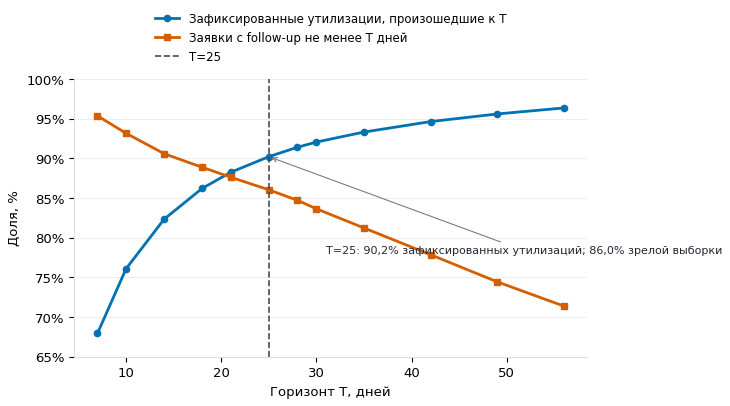

Annotation: T=25: 90,2% зафиксированных утилизаций; 86,0% зрелой выборки


In [13]:
# ============================================================
# 8. График компромисса при выборе порога
# ============================================================

row_ref = threshold_summary_df.loc[threshold_summary_df["T"] == REFERENCE_THRESHOLD].iloc[0]
ann_recorded = 100 * float(row_ref["share_recorded_utilizations_within_T"])
ann_eligible = 100 * float(row_ref["eligible_share"])
annotation_text = (
    f"T={REFERENCE_THRESHOLD}: {ann_recorded:.1f}% зафиксированных утилизаций; "
    f"{ann_eligible:.1f}% зрелой выборки"
).replace(".", ",")  # русская запись десятичных

fig, ax = plt.subplots(figsize=(7.2, 4.2))

x = threshold_summary_df["T"].to_numpy()
y_rec = threshold_summary_df["share_recorded_utilizations_within_T"].to_numpy()
y_elig = threshold_summary_df["eligible_share"].to_numpy()

ax.plot(
    x, y_rec,
    color=PALETTE["line_blue"], linewidth=2.0, marker="o", markersize=4.5,
    label="Зафиксированные утилизации, произошедшие к T",
)
ax.plot(
    x, y_elig,
    color=PALETTE["line_orange"], linewidth=2.0, marker="s", markersize=4.5,
    label="Заявки с follow-up не менее T дней",
)
ax.axvline(
    REFERENCE_THRESHOLD, color=PALETTE["ref_gray"], linestyle="--", linewidth=1.2,
    label=f"T={REFERENCE_THRESHOLD}",
)

ax.set_xlabel("Горизонт T, дней")
ax.set_ylabel("Доля, %")
ax.set_ylim(0.65, 1.00)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_axisbelow(True)
ax.grid(axis="y", color=PALETTE["gray_grid"], linewidth=0.65)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Легенда над графиком, без рамки
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=1,
    frameon=False,
    fontsize=8.5,
)

# Аннотация около T=25
ax.annotate(
    annotation_text,
    xy=(REFERENCE_THRESHOLD, float(row_ref["share_recorded_utilizations_within_T"])),
    xytext=(REFERENCE_THRESHOLD + 6, 0.78),
    fontsize=8,
    color=PALETTE["gray_dark"],
    arrowprops=dict(arrowstyle="->", color=PALETTE["gray"], lw=0.8),
)

fig.tight_layout()
tradeoff_pdf = track_save(FIGURES_DIR / "threshold_tradeoff_publication.pdf")
tradeoff_png = track_save(FIGURES_DIR / "threshold_tradeoff_publication.png")
fig.savefig(tradeoff_pdf, format="pdf")
fig.savefig(tradeoff_png, format="png", dpi=EXPORT_DPI)
# Также в OUTPUT_DIR для удобства
fig.savefig(track_save(OUTPUT_DIR / "threshold_tradeoff_publication.png"), dpi=EXPORT_DPI)
plt.show()
print("Annotation:", annotation_text)


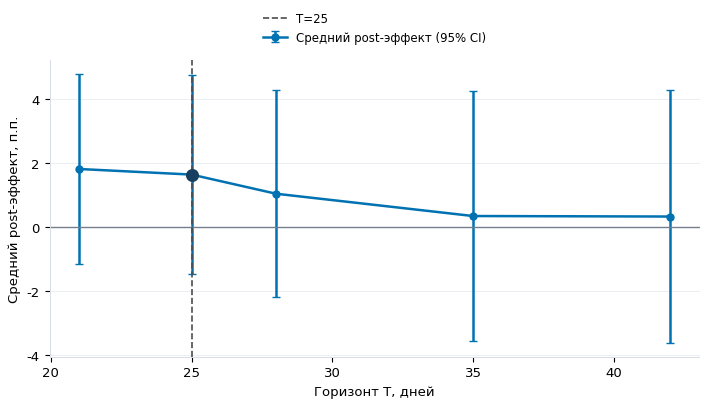

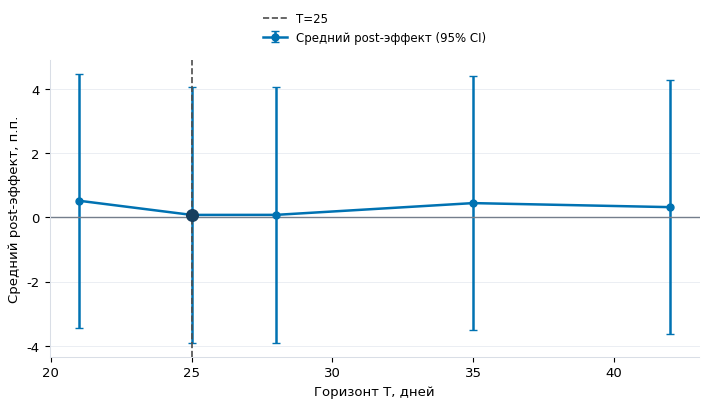

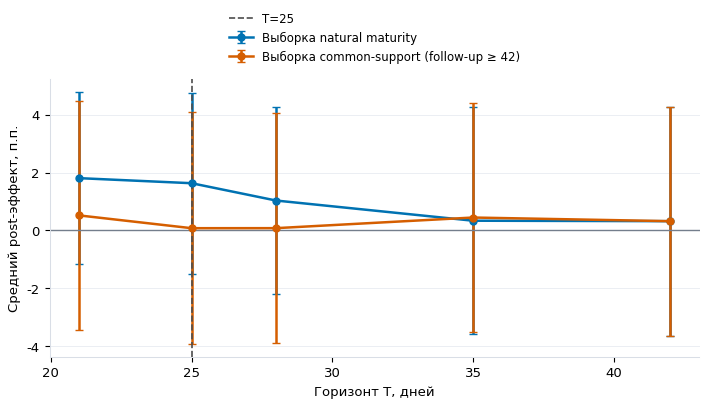

In [14]:
# ============================================================
# 8b. Чувствительность: индивидуальная зрелость и общая поддержка
# ============================================================

@with_plot_style
def plot_did_sensitivity(df: pd.DataFrame, sample_mode: str, stem: str) -> None:
    sub = df.loc[
        (df["sample_mode"] == sample_mode)
        & (df["status"] == "ok")
        & df["avg_post_effect_pp"].notna()
    ].sort_values("T")
    if sub.empty:
        print(f"[SKIP] Нет pooled оценок для {sample_mode}")
        return

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    y = sub["avg_post_effect_pp"].to_numpy()
    yerr = np.vstack([
        y - sub["ci_low_pp"].to_numpy(),
        sub["ci_high_pp"].to_numpy() - y,
    ])
    ax.errorbar(
        sub["T"], y, yerr=yerr,
        fmt="o-", color=PALETTE["line_blue"], ecolor=PALETTE["line_blue"],
        capsize=3, linewidth=1.8, markersize=5,
        label="Средний post-эффект (95% CI)",
    )
    ax.axhline(0, color=PALETTE["gray"], linestyle="-", linewidth=1.0)
    ax.axvline(REFERENCE_THRESHOLD, color=PALETTE["ref_gray"], linestyle="--", linewidth=1.2,
               label=f"T={REFERENCE_THRESHOLD}")

    ref = sub.loc[sub["T"] == REFERENCE_THRESHOLD]
    if not ref.empty:
        ax.scatter(
            ref["T"], ref["avg_post_effect_pp"],
            color=PALETTE["navy"], s=70, zorder=5,
        )

    ax.set_xlabel("Горизонт T, дней")
    ax.set_ylabel("Средний post-эффект, п.п.")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=PALETTE["gray_grid"], linewidth=0.65)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8.5)
    fig.tight_layout()

    for ext in ("pdf", "png"):
        path = FIGURES_DIR / f"{stem}.{ext}"
        if ext == "png":
            fig.savefig(track_save(path), format="png", dpi=EXPORT_DPI)
        else:
            fig.savefig(track_save(path), format="pdf")
    fig.savefig(track_save(OUTPUT_DIR / f"{stem}.png"), dpi=EXPORT_DPI)
    plt.show()


if HAS_LINEARMODELS and did_rows:
    did_threshold_df = pd.DataFrame(did_rows)

    # Два самостоятельных рисунка
    plot_did_sensitivity(
        did_threshold_df, "natural", "did_threshold_sensitivity_natural"
    )
    plot_did_sensitivity(
        did_threshold_df, "common_support", "did_threshold_sensitivity_common_support"
    )

    # Комбинированный рисунок (две линии)
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    style = {
        "natural": (PALETTE["line_blue"], "Выборка natural maturity"),
        "common_support": (PALETTE["line_orange"], "Выборка общей поддержки (период наблюдения ≥ 42)"),
    }
    for mode, (color, label) in style.items():
        sub = did_threshold_df.loc[
            (did_threshold_df["sample_mode"] == mode)
            & (did_threshold_df["status"] == "ok")
            & did_threshold_df["avg_post_effect_pp"].notna()
        ].sort_values("T")
        if sub.empty:
            continue
        y = sub["avg_post_effect_pp"].to_numpy()
        yerr = np.vstack([
            y - sub["ci_low_pp"].to_numpy(),
            sub["ci_high_pp"].to_numpy() - y,
        ])
        ax.errorbar(
            sub["T"], y, yerr=yerr,
            fmt="o-", color=color, ecolor=color, capsize=3,
            linewidth=1.8, markersize=5, label=label,
        )
    ax.axhline(0, color=PALETTE["gray"], linewidth=1.0)
    ax.axvline(REFERENCE_THRESHOLD, color=PALETTE["ref_gray"], linestyle="--", linewidth=1.2,
               label=f"T={REFERENCE_THRESHOLD}")
    ax.set_xlabel("Горизонт T, дней")
    ax.set_ylabel("Средний post-эффект, п.п.")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=PALETTE["gray_grid"], linewidth=0.65)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8.5)
    fig.tight_layout()
    stem = "did_threshold_sensitivity_natural_vs_common"
    fig.savefig(track_save(FIGURES_DIR / f"{stem}.pdf"), format="pdf")
    fig.savefig(track_save(FIGURES_DIR / f"{stem}.png"), format="png", dpi=EXPORT_DPI)
    fig.savefig(track_save(OUTPUT_DIR / f"{stem}.png"), dpi=EXPORT_DPI)
    plt.show()
else:
    print("DiD-графики пропущены")


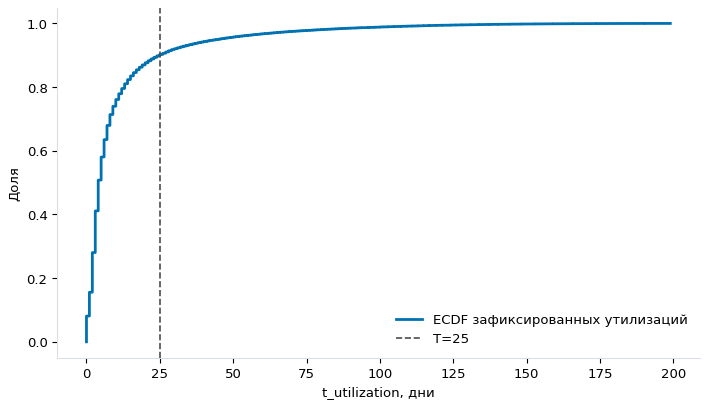

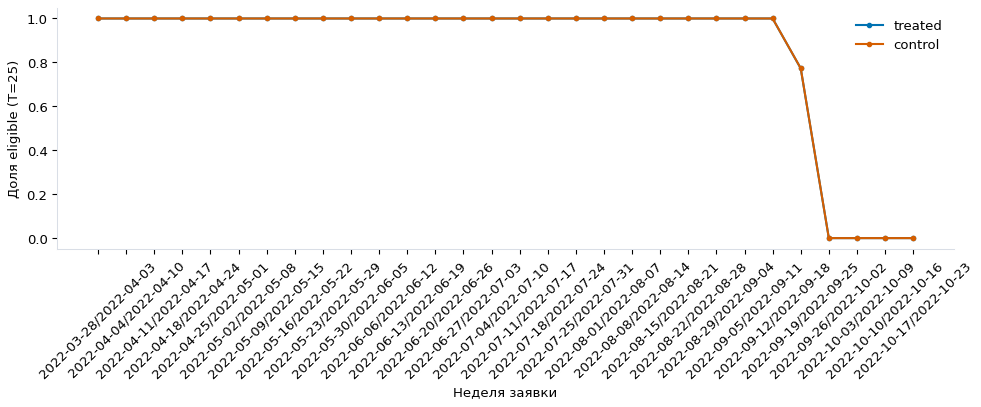

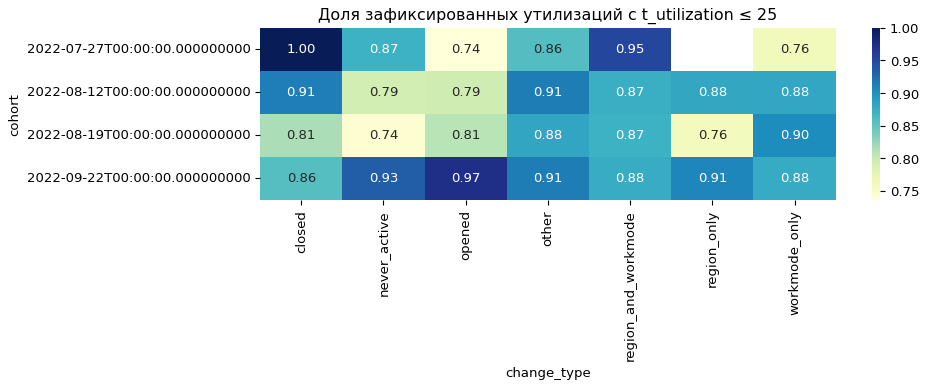

In [15]:
# ============================================================
# 8c. Дополнительные диагностические графики (сохраняем полезные артефакты)
# ============================================================

# ECDF
fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.sort(utilized["t_utilization"].dropna().to_numpy())
y = np.arange(1, len(x) + 1) / len(x)
ax.plot(x, y, color=PALETTE["line_blue"], linewidth=2.0,
        label="ECDF зафиксированных утилизаций")
ax.axvline(REFERENCE_THRESHOLD, color=PALETTE["ref_gray"], linestyle="--", linewidth=1.2,
           label=f"T={REFERENCE_THRESHOLD}")
ax.set_xlabel("t_utilization, дни")
ax.set_ylabel("Доля")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(track_save(OUTPUT_DIR / "ecdf_t_utilization.png"), dpi=150)
plt.show()

# Eligible by week
week_df = (
    apps.assign(eligible_25=eligible_25)
    .groupby(["request_week", "is_treated"])["eligible_25"]
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 4.2))
for treated, label, color in [
    (True, "treated", PALETTE["line_blue"]),
    (False, "control", PALETTE["line_orange"]),
]:
    sub = week_df[week_df["is_treated"] == treated]
    ax.plot(sub["request_week"], sub["eligible_25"], marker="o", ms=3, label=label, color=color)
ax.set_xlabel("Неделя заявки")
ax.set_ylabel(f"Доля eligible (T={REFERENCE_THRESHOLD})")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(track_save(OUTPUT_DIR / "eligible_25_by_request_week.png"), dpi=150)
plt.show()

# Heatmap
heat = (
    utilized.assign(within_25=utilized["t_utilization"] <= REFERENCE_THRESHOLD)
    .groupby(["cohort", "change_type"])["within_25"]
    .mean()
    .unstack(fill_value=np.nan)
)
fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(heat))))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title(f"Доля зафиксированных утилизаций с t_utilization ≤ {REFERENCE_THRESHOLD}")
fig.tight_layout()
fig.savefig(track_save(OUTPUT_DIR / "heatmap_captured_25_cohort_change_type.png"), dpi=150)
heat.to_csv(track_save(OUTPUT_DIR / "heatmap_captured_25_cohort_change_type.csv"))
plt.show()


In [16]:
# ============================================================
# 9. Итоговый вывод
# ============================================================

captured_25 = float(row_25["share_recorded_utilizations_within_T"])
tail_25 = float(row_25["tail_share_after_T"])
eligible_all = float(eligible_summary["eligible_share_all"])
treated_key = True if True in tc.index else 1
control_key = False if False in tc.index else 0
tc_gap_val = float(abs(tc.loc[treated_key, "eligible_share"] - tc.loc[control_key, "eligible_share"]))

# p90 контекст
p90_t = float(overall_stats["p90"].iloc[0]) if "p90" in overall_stats.columns else np.nan

did_note = ""
if HAS_LINEARMODELS and did_rows:
    ddf = pd.DataFrame(did_rows)
    nat = ddf[(ddf["sample_mode"] == "natural") & (ddf["T"] == REFERENCE_THRESHOLD)]
    com = ddf[(ddf["sample_mode"] == "common_support") & (ddf["T"] == REFERENCE_THRESHOLD)]
    if not nat.empty and pd.notna(nat.iloc[0].get("avg_post_effect_pp")):
        did_note += (
            f"- **DiD natural (T=25), средний post-эффект:** "
            f"{nat.iloc[0]['avg_post_effect_pp']:.2f} п.п. "
            f"[{nat.iloc[0]['ci_low_pp']:.2f}; {nat.iloc[0]['ci_high_pp']:.2f}].\n"
        )
    if not com.empty and pd.notna(com.iloc[0].get("avg_post_effect_pp")):
        did_note += (
            f"- **DiD common-support (T=25), средний post-эффект:** "
            f"{com.iloc[0]['avg_post_effect_pp']:.2f} п.п. "
            f"[{com.iloc[0]['ci_low_pp']:.2f}; {com.iloc[0]['ci_high_pp']:.2f}].\n"
        )

conclusion = f"""
### Итоговые выводы по горизонту зрелости утилизации

- **T={REFERENCE_THRESHOLD} соответствует 90-му процентилю только распределения уже зафиксированных утилизаций** (эмпирический p90 лага ≈ {p90_t:.1f} дн. среди утилизаций, зафиксированных до административного окончания наблюдения {UTILIZATION_OBSERVATION_END.date()}).
- **{tail_25:.2%} зафиксированных утилизаций происходят позже {REFERENCE_THRESHOLD} дней** (share_recorded_utilizations_within_T = {captured_25:.2%}).
- **{eligible_all:.2%} заявок имеют необходимый {REFERENCE_THRESHOLD}-дневный follow-up** (`request + {REFERENCE_THRESHOLD}d ≤ {UTILIZATION_OBSERVATION_END.date()}`).
- **Разрыв доли зрелых заявок между группами воздействия и контроля мал:** абсолютная разница доля зрелых заявок = {tc_gap_val:.2%}.
- **T={REFERENCE_THRESHOLD} определяет {REFERENCE_THRESHOLD}-дневную конверсию в утилизацию, а не утилизацию за весь доступный период.** Исход — `utlz_within_T` на зрелой выборке `eligible_T`.
- **Поздние когорты имеют ограниченный постподдержку.** В частности, когорта 2022-09-22 при T=25 имеет effective request cutoff {(UTILIZATION_OBSERVATION_END - pd.Timedelta(days=25)).date()} и не даёт полноценного post-окна.
- **Оценки чувствительности интерпретируются только после унификации выборки (индивидуальная зрелость и общая поддержка), единого post-окна и корректного covariance-based SE** для среднего post-эффекта.
{did_note}
_Административное окончание наблюдения:_ `{UTILIZATION_OBSERVATION_END.date()}`.
_Основной горизонт:_ `REFERENCE_THRESHOLD = {REFERENCE_THRESHOLD}` (задан заранее, не выбран автоматически как «оптимальный»).
"""

display(Markdown(conclusion))
with open(track_save(OUTPUT_DIR / "conclusion.md"), "w", encoding="utf-8") as f:
    f.write(conclusion)

# Список созданных файлов
unique_files = sorted({p.resolve() for p in CREATED_FILES})
files_df = pd.DataFrame({
    "file": [str(p) for p in unique_files],
    "exists": [p.exists() for p in unique_files],
})
display(files_df)
files_df.to_csv(track_save(OUTPUT_DIR / "created_files_list.csv"), index=False)

print("\nСозданные / обновлённые файлы:")
for p in unique_files:
    print(("  [OK] " if p.exists() else "  [MISSING] ") + str(p))
print("\nВсе результаты сохранены в:", OUTPUT_DIR)
print("Публикационные графики:", FIGURES_DIR)



### Итоговые выводы по горизонту зрелости утилизации

- **T=25 соответствует 90-му процентилю только распределения уже зафиксированных утилизаций** (эмпирический p90 лага ≈ 25.0 дн. среди утилизаций, зафиксированных до административного окончания наблюдения 2022-10-18).
- **9.78% зафиксированных утилизаций происходят позже 25 дней** (share_recorded_utilizations_within_T = 90.22%).
- **86.04% заявок имеют необходимый 25-дневный follow-up** (`request + 25d ≤ 2022-10-18`).
- **Разрыв доли зрелых заявок между группами воздействия и контроля мал:** абсолютная разница доля зрелых заявок = 0.10%.
- **T=25 определяет 25-дневную конверсию в утилизацию, а не утилизацию за весь доступный период.** Исход — `utlz_within_T` на зрелой выборке `eligible_T`.
- **Поздние когорты имеют ограниченный постподдержку.** В частности, когорта 2022-09-22 при T=25 имеет effective request cutoff 2022-09-23 и не даёт полноценного post-окна.
- **Оценки чувствительности интерпретируются только после унификации выборки (индивидуальная зрелость и общая поддержка), единого post-окна и корректного covariance-based SE** для среднего post-эффекта.
- **DiD natural (T=25), средний post-эффект:** 1.63 п.п. [-1.49; 4.75].
- **DiD common-support (T=25), средний post-эффект:** 0.08 п.п. [-3.93; 4.08].

_Административное окончание наблюдения:_ `2022-10-18`.
_Основной горизонт:_ `REFERENCE_THRESHOLD = 25` (задан заранее, не выбран автоматически как «оптимальный»).


[HTML-таблица сокращена: ~42 строк; см. сохранённый CSV при наличии экспорта]


Созданные / обновлённые файлы:
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…
  [OK] <PROJECT_ROOT>/…

… [output сокращён: было 47 строк / 1127 символов; полный результат сохранён в CSV/фигурах при наличии экспорта] …

## Вывод

Основной горизонт `REFERENCE_THRESHOLD = 25` задан заранее как T-дневная
конверсия в утилизацию среди заявок с достаточным периодом наблюдения, а не как
оптимальный порог или утилизация за весь доступный период. Доля зрелых заявок и
разрыв между группами воздействия и контроля малы; поздние когорты имеют
ограниченное окно после воздействия. Оценки по альтернативным T сопоставляются
после унификации выборки и постпериода. Подробные численные итоги сохраняются в
`outputs/utilization_censoring/conclusion.md`.
